<a href="https://colab.research.google.com/github/Gautamkhushboo/Machine-Vision-LAB/blob/main/PRELAB_1_(MV_25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python numpy matplotlib

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-06-22 122847.png to Screenshot 2026-06-22 122847.png


In [ ]:
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

print("Image loaded successfully")

Image loaded successfully


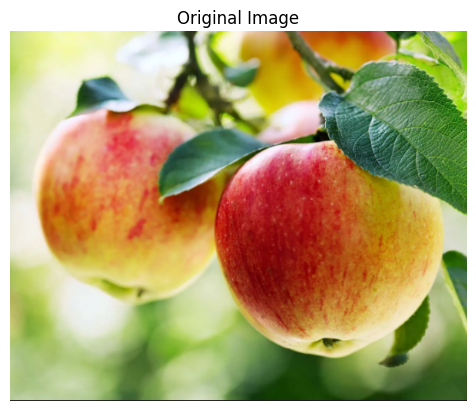

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
print("Shape (Height, Width, Channels):", img.shape)
print("Image Size:", img.size)
print("Data Type:", img.dtype)

Shape (Height, Width, Channels): (432, 534, 3)
Image Size: 692064
Data Type: uint8


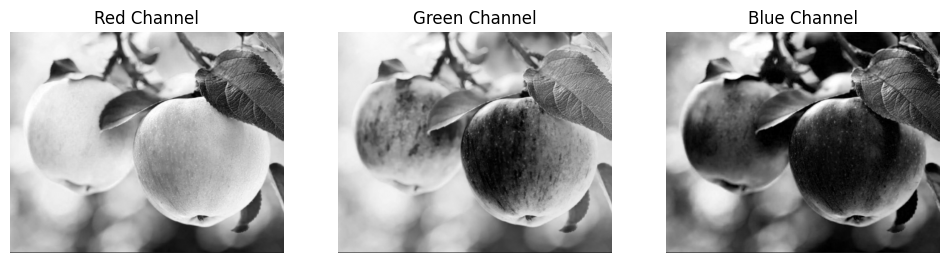

In [ ]:
b, g, r = cv2.split(img)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(r, cmap='gray')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(g, cmap='gray')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(b, cmap='gray')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

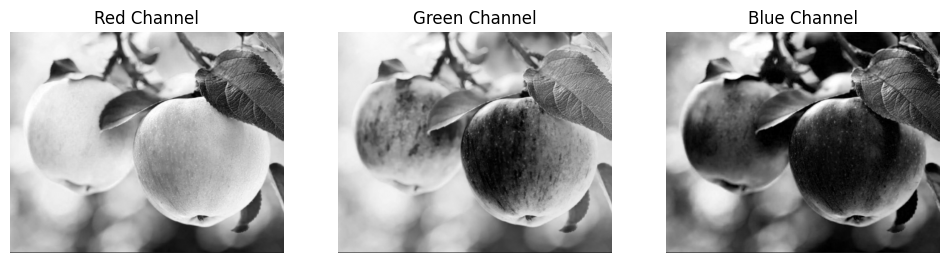

In [ ]:
b, g, r = cv2.split(img)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(r, cmap='gray')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(g, cmap='gray')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(b, cmap='gray')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

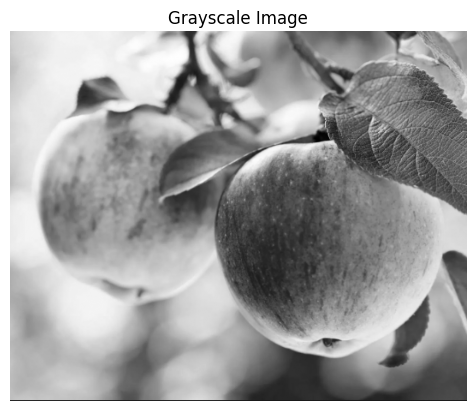

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import io

In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename